# DDIM Model

In [1]:
import sys, os
print(sys.executable)
print(sys.version)
print(os.environ.get("HF_HOME"))

/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/bin/python
3.10.12 (main, Jul 20 2023, 10:11:55) [GCC 8.5.0 20210514 (Red Hat 8.5.0-18)]
/scratch/hbbeth/huggingface


In [2]:
import os

os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/huggingface"
os.environ["TRANSFORMERS_CACHE"] = os.environ["HF_HOME"]
os.environ["HUGGINGFACE_HUB_CACHE"] = os.environ["HF_HOME"]

print(os.environ["HF_HOME"])

/scratch/hbbeth/huggingface


In [3]:
from diffusers import DDIMScheduler, StableDiffusionPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [4]:
from diffusers import DDIMScheduler, StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

print("pipeline loaded")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /scratch/hbbeth/huggingface/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /scratch/hbbeth/huggingface/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pipeline loaded


  0%|          | 0/20 [00:00<?, ?it/s]

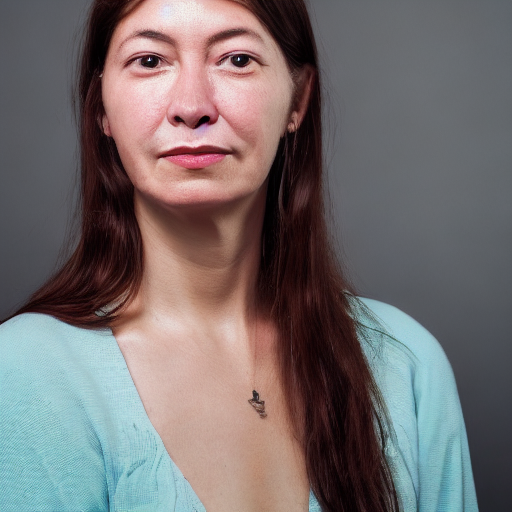

In [5]:
image = pipe(
    "a portrait photo of a woman",
    num_inference_steps=20
).images[0]

image

In [5]:
from PIL import Image, ImageFilter

img_path = "/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/img_align_celeba/000001.jpg"
img = Image.open(img_path).convert("RGB")
img = img.resize((512, 512))

blurred = img.filter(ImageFilter.GaussianBlur(radius=3))

img, blurred

(<PIL.Image.Image image mode=RGB size=512x512>,
 <PIL.Image.Image image mode=RGB size=512x512>)

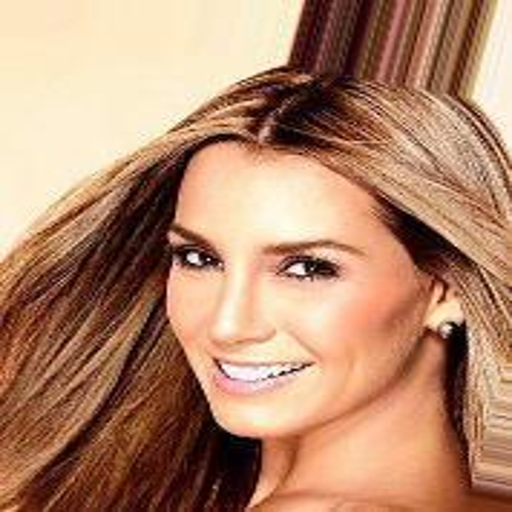

In [6]:
img

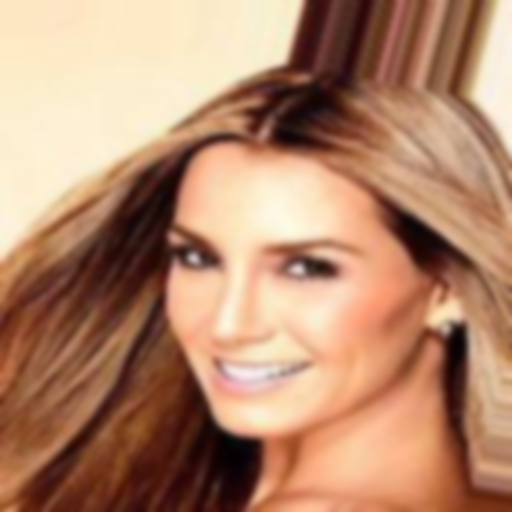

In [7]:
blurred

In [8]:
from diffusers import StableDiffusionImg2ImgPipeline, DDIMScheduler
import torch

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

print("img2img pipeline ready")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /scratch/hbbeth/huggingface/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /scratch/hbbeth/huggingface/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


img2img pipeline ready


  0%|          | 0/10 [00:00<?, ?it/s]

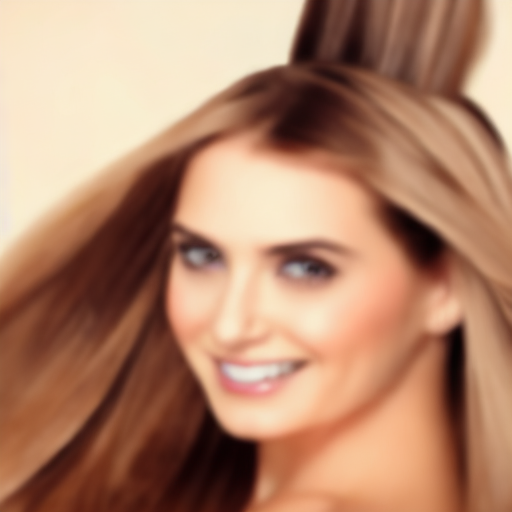

In [9]:
output = pipe(
    prompt="a portrait photo of a person",
    image=blurred,
    strength=0.5,
    num_inference_steps=20
).images[0]

output

# Unconditional DDIM

In [10]:
import os
import torch
from diffusers import DDPMPipeline, DDIMScheduler

os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/huggingface"
os.environ["TRANSFORMERS_CACHE"] = os.environ["HF_HOME"]
os.environ["HUGGINGFACE_HUB_CACHE"] = os.environ["HF_HOME"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

pipe = DDPMPipeline.from_pretrained(
    "google/ddpm-celebahq-256"
).to(device)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

print("unconditional DDIM pipeline ready")

device: cuda


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /scratch/hbbeth/huggingface/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /scratch/hbbeth/huggingface/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


unconditional DDIM pipeline ready


  0%|          | 0/20 [00:00<?, ?it/s]

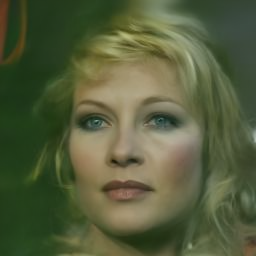

In [12]:
image = pipe(num_inference_steps=20).images[0]
image